In [67]:
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

    dateTime      value
0 2014-08-18  10.125083
1 2014-08-19  10.120875
2 2014-08-20  10.116500
3 2014-08-21  10.120417
4 2014-08-22  10.112250


Text(0.5, 1.0, 'Daily Average Values Over Time')

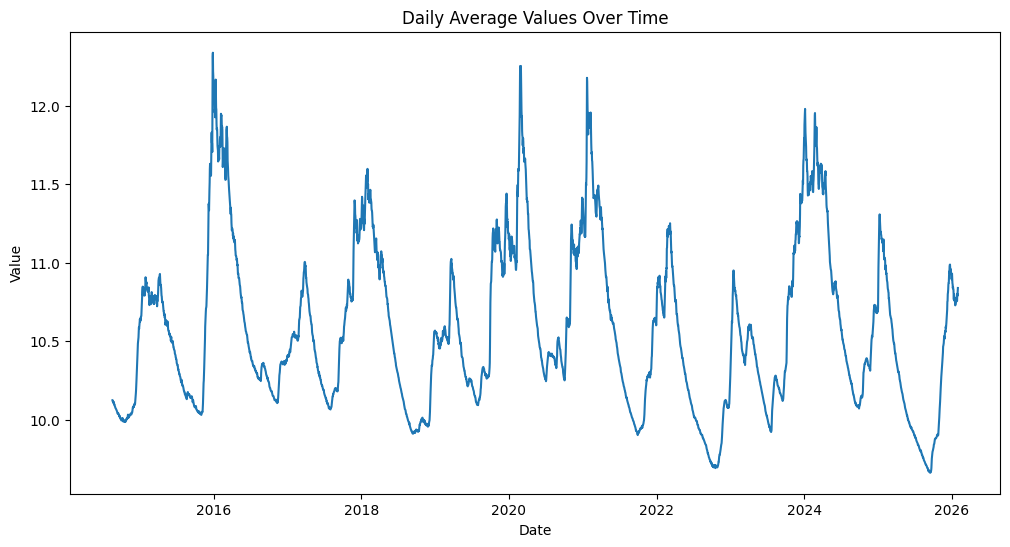

In [68]:
#importing the data
readwood_df = pd.read_csv('ReadScarWood.csv')

#print(readwood_df.head())
#print(readwood_df.info())
#print(readwood_df.describe())

readwood_df['dateTime'] = pd.to_datetime(readwood_df['dateTime'])

#finding the average value for each day
daily = readwood_df.groupby(readwood_df['dateTime'].dt.date)["value"].mean().reset_index()

daily["dateTime"] = pd.to_datetime(daily["dateTime"])


daily = daily.sort_values(by='dateTime', ascending=True)

print(daily.head())

#plotting the cleaned data
plt.figure(figsize=(12, 6))
plt.plot(daily["dateTime"], daily["value"])
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Daily Average Values Over Time')

ACF values for selected lags:
  Lag 1: 0.9986273433697388
  Lag 7: 0.9762923793247695
  Lag 30: 0.826740785552347
  Lag 90: 0.2548463348657063
  Lag 365: 0.28516356695350836
PACF values for selected lags:
  Lag 1: 0.9988660780920362
  Lag 7: -0.06523855219651334
  Lag 30: -0.024958341734578542
  Lag 90: 0.003627553446537731
  Lag 365: 0.20132684631892994


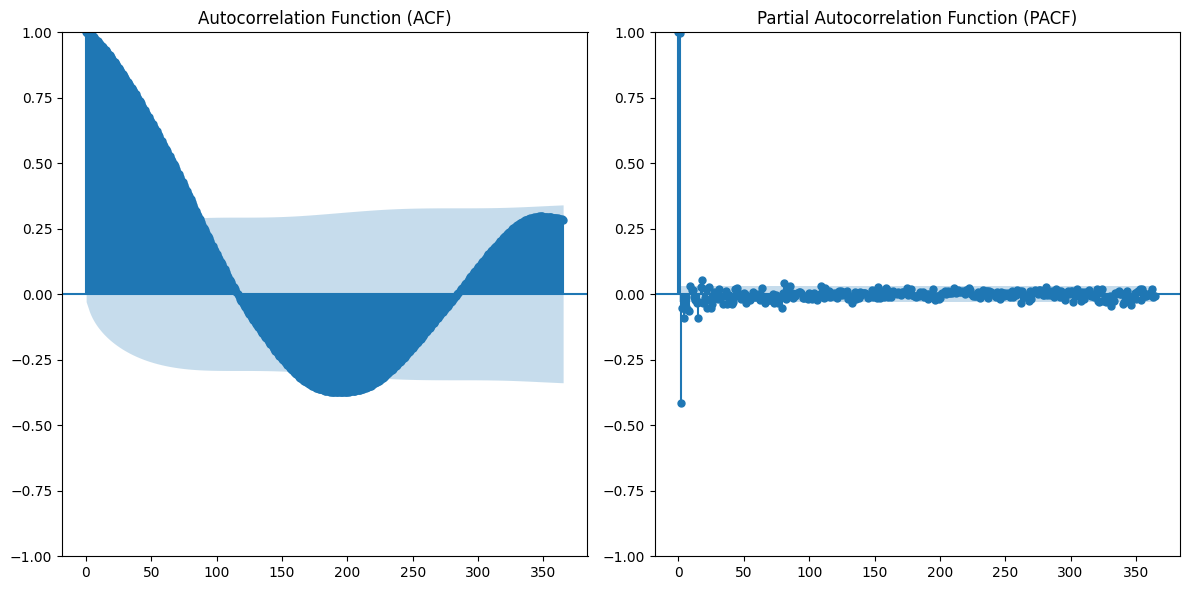

In [69]:
#finding the right lag for the model

acf_values = acf(daily["value"].dropna(), nlags=365)
pacf_values = pacf(daily["value"].dropna(), nlags=365)

lags = [1, 7, 30, 90, 365]  # Example lags: 1 day, 1 week, 1 month, 1 year, 4 years

print("ACF values for selected lags:")
for lag in lags:
    print(f"  Lag {lag}: {acf_values[lag]}")

print("PACF values for selected lags:")
for lag in lags:
    print(f"  Lag {lag}: {pacf_values[lag]}")

#plot ACF and PACF
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(daily["value"].dropna(), lags=365, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')

plt.subplot(1, 2, 2)
plot_pacf(daily["value"].dropna(), lags=365, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

In [70]:
#lags to use: [1, 7, 30, 365]

daily['lag_1'] = daily['value'].shift(1)
daily['lag_7'] = daily['value'].shift(7)
daily['lag_30'] = daily['value'].shift(30)
daily['lag_365'] = daily['value'].shift(365)

daily["rolling_mean_7"] = daily["value"].shift(1).rolling(window=7).mean()
daily["rolling_mean_30"] = daily["value"].shift(1).rolling(window=30).mean()
#daily["rolling_mean_365"] = daily["value"].shift(1).rolling(window=365).mean()
daily["rolling_std_7"] = daily["value"].shift(1).rolling(window=7).std()
daily["rolling_std_30"] = daily["value"].shift(1).rolling(window=30).std()



In [71]:
daily = daily.dropna()

#x = daily[['lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7']]
x = daily[['lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7']]
y = daily['value']

train_split = int(len(daily) * 0.6)
val_split = int(len(daily) * 0.8)

x_train, y_train = x.iloc[:train_split], y.iloc[:train_split]
x_val, y_val = x.iloc[train_split:val_split], y.iloc[train_split:val_split]
x_test, y_test = x.iloc[val_split:], y.iloc[val_split:]


Train MSE: 0.0012388394518625713
Validation MSE: 0.004727089895665242
Test MSE: 0.00525973313817204


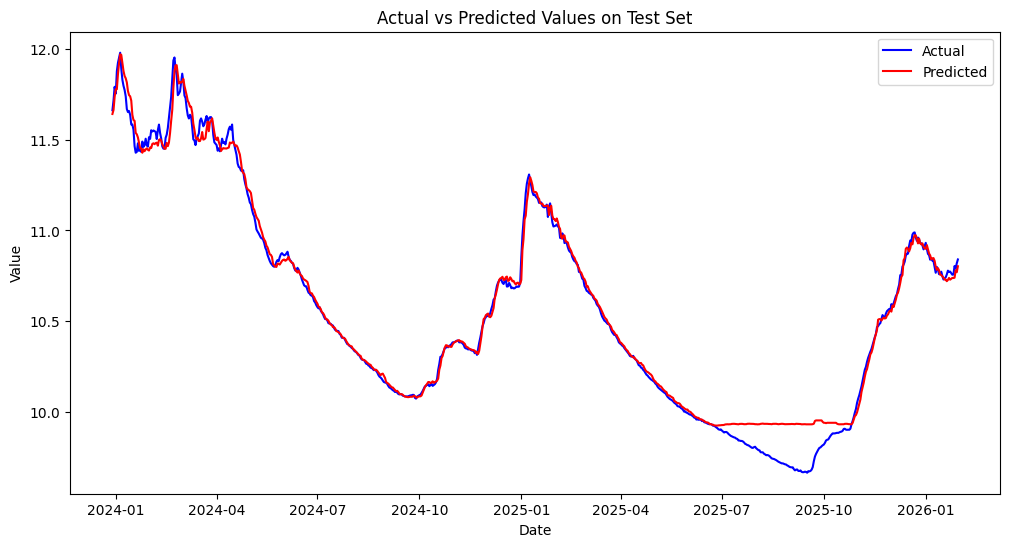

In [72]:
model = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_split=30, min_samples_leaf=15, max_features='sqrt', random_state=42)
#model = RandomForestRegressor(n_estimators=100, max_depth=8, max_features='sqrt', random_state=42)
#model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(x_train, y_train)

train_predictions = model.predict(x_train)
val_predictions = model.predict(x_val)
test_predictions = model.predict(x_test)

train_mse = mean_squared_error(y_train, train_predictions)
val_mse = mean_squared_error(y_val, val_predictions)
test_mse = mean_squared_error(y_test, test_predictions)

print(f"Train MSE: {train_mse}")
print(f"Validation MSE: {val_mse}")
print(f"Test MSE: {test_mse}")

 #plotting graph

plt.figure(figsize=(12, 6))
plt.plot(daily["dateTime"].iloc[val_split:], y_test, label='Actual', color='blue')
plt.plot(daily["dateTime"].iloc[val_split:], test_predictions, label='Predicted', color='red')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values on Test Set')
plt.legend()